In [17]:
import pandas as pd

df = pd.read_csv("../Data/cleaned_data.csv")

In [18]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Calculate skewness for each column
skewness_values = numeric_cols.skew()

# Display skewness nicely
print("📈 Skewness of Numeric Columns:\n")
for col, val in skewness_values.items():
    print(f"🔹 {col}: {val:.2f}")

📈 Skewness of Numeric Columns:

🔹 Customer_Age: -0.00
🔹 Delivery_Time_Min: 0.50
🔹 Distance_km: 0.99
🔹 Order_Value: 0.46
🔹 Discount_Applied: 1.40
🔹 Final_Amount: 0.46
🔹 Delivery_Rating: 0.00
🔹 Restaurant_Rating: 0.00
🔹 Profit_Margin: 0.39
🔹 Calculated_Amount: 0.46


🟢 Normal / Symmetric

Customer_Age

Delivery_Rating

Restaurant_Rating

🟡 Slightly Skewed (Acceptable)

Delivery_Time_Min

Order_Value

Final_Amount

Profit_Margin

Calculated_Amount

🔴 Highly Skewed (Investigate)

Distance_km

Discount_Applied

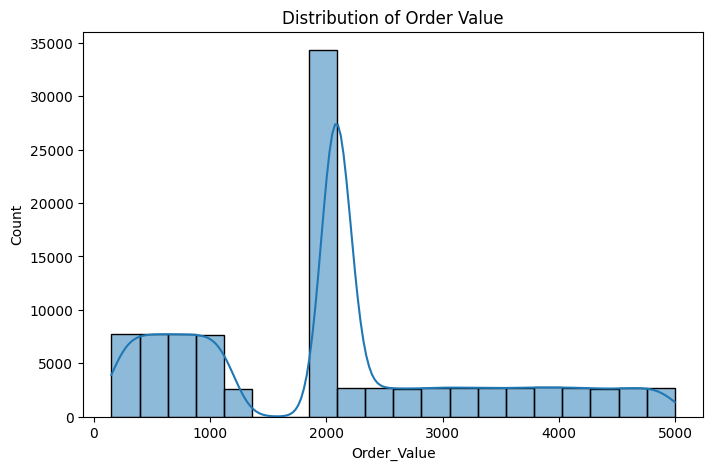

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["Order_Value"], kde=True, bins=20)
plt.title("Distribution of Order Value")
plt.show()

### Order Value Distribution Insight

The order value distribution is moderately right-skewed with visible spending clusters. 
A significant concentration of orders occurs around ₹2000, suggesting a dominant mid-tier pricing segment.

Lower-value and premium orders are also present, indicating multi-tier customer spending behavior. 
This segmentation could be leveraged for targeted promotions and pricing strategies.

In [20]:
df["Order_Value"].describe()

count    100000.000000
mean       2081.830126
std        1268.589761
min         150.000000
25%         935.000000
50%        2081.830126
75%        2743.000000
max        5000.000000
Name: Order_Value, dtype: float64

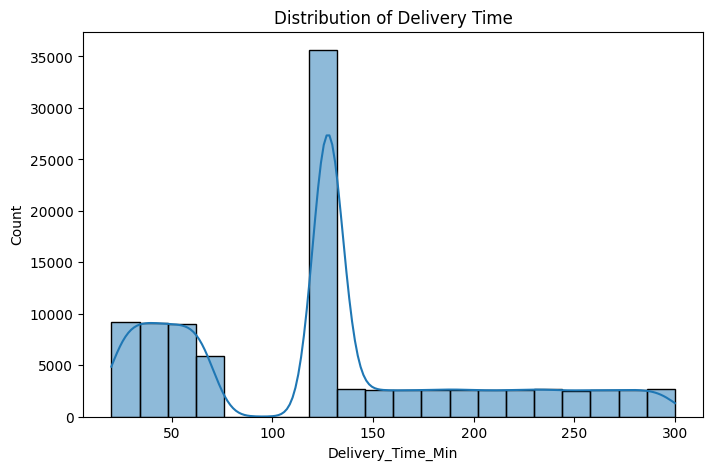

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_Time_Min"], kde=True, bins=20)
plt.title("Distribution of Delivery Time")
plt.show()

In [22]:
df["Delivery_Time_Min"].describe()

count    100000.000000
mean        127.475923
std          74.128198
min          20.000000
25%          58.000000
50%         127.475923
75%         165.000000
max         300.000000
Name: Delivery_Time_Min, dtype: float64

### Delivery Time Analysis

The average delivery time is 127 minutes, with a wide standard deviation of 74 minutes, indicating high variability in service performance.

While 25% of orders are delivered within 58 minutes, another 25% exceed 165 minutes, highlighting significant inconsistency in operational efficiency.

The maximum delivery time of 300 minutes suggests the presence of extreme delays, which could negatively impact customer satisfaction and retention.

Improving delivery time consistency should be a strategic operational priority.

In [27]:
City_summary = df.groupby("City").agg({
    "Order_Value": "mean",
    "Final_Amount": "sum",
    "Profit_Margin": "mean"
}).sort_values(by="Final_Amount", ascending=False)

City_summary

,Order_Value,Final_Amount,Profit_Margin
City,,,
hyderabad,2077.958761,6.719354e+07,0.178811
bangalore,2088.016489,3.363363e+07,0.178584
delhi,2076.248615,3.336412e+07,0.178633
chennai,2090.908308,3.314183e+07,0.177788
mumbai,2080.027666,3.302641e+07,0.180407


In [25]:
cuisine_summary = df.groupby("Cuisine_Type").agg({
    "Order_Value":"mean",
    "Final_Amount":"sum",
    "Profit_Margin":"mean"
}).sort_values(by="Final_Amount", ascending=False)

cuisine_summary

,Order_Value,Final_Amount,Profit_Margin
Cuisine_Type,,,
indian,2089.282223,6.750928e+07,0.178018
chinese,2079.152876,3.331941e+07,0.178308
mexican,2084.289130,3.330727e+07,0.180124
arabian,2068.518828,3.315124e+07,0.178950
italian,2080.336527,3.307233e+07,0.179634


Hyderabad drives volume and revenue, while Mumbai delivers better profitability.
Indian cuisine drives revenue volume, while Mexican cuisine contributes higher profitability.

In [29]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Day_Type"] = df["Order_Date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)
week_comparison = df.groupby("Day_Type").agg({
    "Order_ID": "count",
    "Order_Value": "mean",
    "Final_Amount": "sum",
    "Profit_Margin": "mean"
}).rename(columns={
    "Order_ID": "Total_Orders",
    "Order_Value": "Avg_Order_Value",
    "Final_Amount": "Total_Revenue",
    "Profit_Margin": "Avg_Profit_Margin"
})

week_comparison

,Total_Orders,Avg_Order_Value,Total_Revenue,Avg_Profit_Margin
Day_Type,,,,
Weekday,71632,2083.279452,1.436406e+08,0.178986
Weekend,28368,2078.170435,5.671894e+07,0.178466


In [ ]:
Weekdays have much higher demand, 
Almost identical spending behavior, 
Revenue is significantly higher on weekdays, 
Margins are nearly the same

In [39]:
cancelled_df = df[
    (df["Order_Status"].str.lower() == "cancelled") &
    (df["Cancellation_Reason"].str.lower() != "not cancelled")
]
final_cancel_analysis = cancelled_df.groupby("Cancellation_Reason").agg({
    "Order_ID": "count",
    "Final_Amount": "sum"
})

final_cancel_analysis = final_cancel_analysis.rename(columns={
    "Order_ID": "Total_Cancellations",
    "Final_Amount": "Revenue_Loss"
})

final_cancel_analysis.sort_values(by="Total_Cancellations", ascending=False)


,Total_Cancellations,Revenue_Loss
Cancellation_Reason,,
late delivery,3059,6.134212e+06
customer cancelled,2993,6.029434e+06
restaurant issue,2979,5.942014e+06


Late Delivery is the highest real cancellation reason.

Customer cancellations and restaurant issues are almost equal.

Revenue loss from late delivery is slightly higher than other reasons.

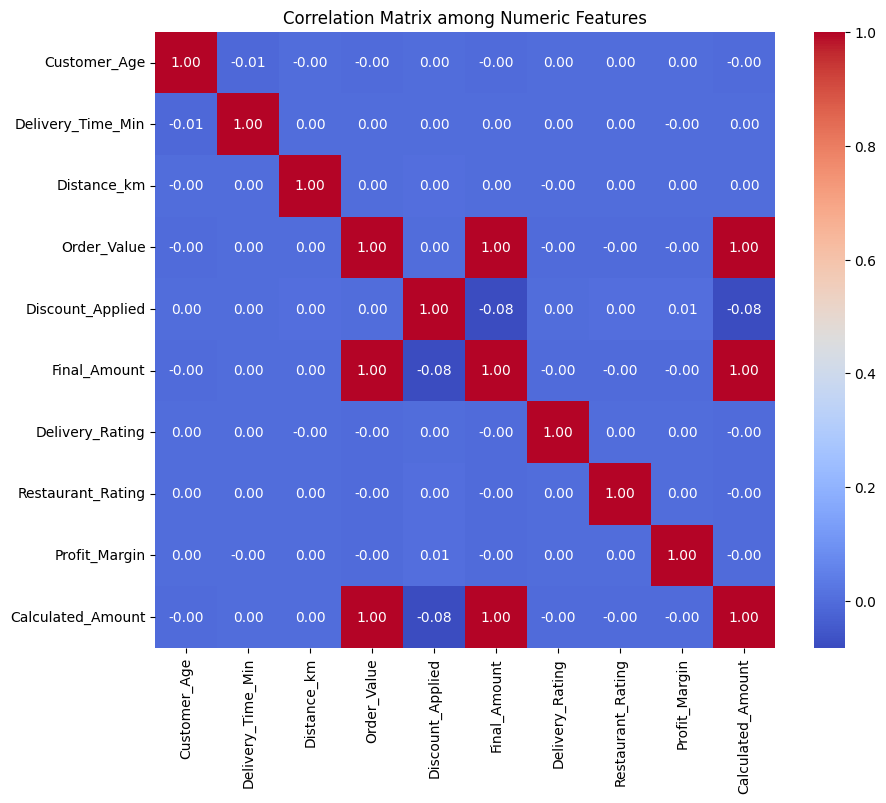

In [42]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols
corr_matrix = df[numeric_cols].corr(method='pearson')
corr_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix among Numeric Features")
plt.show()

Order_Value, Final_Amount, and Calculated_Amount are all perfectly correlated (correlation = 1).
Most other numeric features (like Customer_Age, Delivery_Time_Min, Distance_km, Delivery_Rating, Restaurant_Rating, Profit_Margin) show correlations near 0 with each other.
Discount_Applied shows very slight negative correlation (~ -0.08) with Final_Amount and Calculated_Amount.

In [45]:
df['Profit_Margin_Percentage'] = (df['Profit_Margin'] / df['Final_Amount']) * 100

In [46]:
age_group_list = []

for age in df['Customer_Age']:
    if age < 25:
        age_group_list.append('Youth')
    elif age <= 45:
        age_group_list.append('Adult')
    else:
        age_group_list.append('Senior')

df['Customer_Age_Group'] = age_group_list

In [48]:
delivery_category = []

for time in df["Delivery_Time_Min"]:
    if time <= 45:
        delivery_category.append("Fast")
    elif time <= 75:
        delivery_category.append("Normal")
    else:
        delivery_category.append("Slow")

df["Delivery_Performance"] = delivery_category

In [49]:
df[["Day_Type","Peak_Hour","Delivery_Performance","Profit_Margin_Percentage","Customer_Age_Group"]]


,Day_Type,Peak_Hour,Delivery_Performance,Profit_Margin_Percentage,Customer_Age_Group
0,Weekend,True,Slow,0.006245,Youth
1,Weekday,True,Fast,0.009899,Adult
2,Weekend,True,Slow,0.010855,Adult
3,Weekday,False,Slow,0.001921,Adult
4,Weekend,False,Normal,0.034091,Senior
...,...,...,...,...,...
99995,Weekday,True,Slow,0.128788,Adult
99996,Weekday,False,Normal,0.000000,Adult
99997,Weekday,True,Fast,0.022795,Adult
99998,Weekday,False,Normal,0.022202,Adult


In [50]:
df.to_csv("feature_engineering.csv", index=False)